# 1. Data Perparation and Integration

In [4]:
import pandas as pd
import numpy as np

# For training our models
from sklearn.model_selection import train_test_split

# Used for modeling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [5]:
# Load datasets
df_contract = pd.read_csv('./datasets/contract.csv')
df_personal = pd.read_csv('./datasets/personal.csv')
df_internet = pd.read_csv('./datasets/internet.csv')
df_phone = pd.read_csv('./datasets/phone.csv')

In [6]:
df_contract.columns.tolist()

['customerID',
 'BeginDate',
 'EndDate',
 'Type',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [7]:
# Verify customer ID keys
df_contract['customerID'].nunique()

7043

In [8]:
len(df_contract)

7043

#### No appearant duplicates found

In [9]:
df_contract['BeginDate'].value_counts()

BeginDate
2014-02-01    366
2019-10-01    237
2019-11-01    237
2019-09-01    237
2020-01-01    233
             ... 
2020-02-01     11
2014-01-01      7
2013-10-01      3
2013-12-01      3
2013-11-01      2
Name: count, Length: 77, dtype: int64

In [10]:
df_contract['BeginDate'].dtype

dtype('O')

In [11]:
# Clean dataypes
df_contract['BeginDate'] = pd.to_datetime(df_contract['BeginDate'], errors='coerce')

In [12]:
df_contract['BeginDate'].dtype

dtype('<M8[ns]')

In [13]:
df_contract['BeginDate'].isna().sum()

np.int64(0)

### We run this code to see how the date field looks like. As we can see it has the following format: 'yyyy-mm-dd'. We converted the 'BeginDate' into a Datetime. 

In [14]:
df_personal.columns.tolist()

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']

In [15]:
df_internet.columns.tolist()

['customerID',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']

In [16]:
df_phone.columns.tolist()

['customerID', 'MultipleLines']

In [17]:
frames = [df_contract, df_personal, df_internet, df_phone]

# Start with contract (base table)
df = df_contract.merge(df_personal, on='customerID', how='left')

# Add internet services
df = df.merge(df_internet, on='customerID', how='left')

# Add phone services
df = df.merge(df_phone, on='customerID', how='left')

In [18]:
# Merge table into a single data frame
print(df.columns)

Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'MultipleLines'],
      dtype='object')


In [19]:
df['customerID']

0       7590-VHVEG
1       5575-GNVDE
2       3668-QPYBK
3       7795-CFOCW
4       9237-HQITU
           ...    
7038    6840-RESVB
7039    2234-XADUH
7040    4801-JZAZL
7041    8361-LTMKD
7042    3186-AJIEK
Name: customerID, Length: 7043, dtype: object

In [20]:
df['TotalCharges'].dtype

dtype('O')

#### I had to turn this from text to numbers. This might be usesful moving forward in our analysis. 

In [21]:
# BeginDate -> datetime
df['BeginDate'] = pd.to_datetime(df_contract['BeginDate'], errors='coerce')

# EndDate (target variable) -> I made a datetime version of 'EndDate_dt'
df['EndDate_dt'] = pd.to_datetime(df_contract['EndDate'].replace('No', pd.NaT), errors='coerce')

#### If the cusomter has turned, then a date will show. This is why I created 'EndDate_dt' (it's a date time version of 'EndDate' and it can be used to avoid issues and to match 'BeginDate')

In [22]:
df['churn'] = (df_contract['EndDate'] != 'No').astype(int)
print(df['churn'])  # Print from df, not df_contract

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64


In [23]:

print("Churn Distribution")
print(df['churn'].value_counts())  # Use 'churn' instead of 'Churn'
print("\nChurn Percentage")
print(df['churn'].value_counts(normalize=True) * 100)


Churn Distribution
churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentage
churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64



### The dataset contains approximately 26% churn cases and 74% non-churn cases.  
- This class imbalance can bias models toward predicting the majority class, which is why evaluating metrics such as F1 score, recall, and ROC-AUC will be emphasized instead of relying solely on accuracy.


# 2. Exploratory Data Analysis (EDA)

In [24]:
df['churn'].value_counts(normalize=True)

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

### This so far indicates a 26% churn. This also means that our data is NOT heavily scewed. WE can work with this sligh imbalance. 

In [25]:
pd.crosstab(df['Type'], df['churn'], normalize='index')

churn,0,1
Type,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


#### Here is one categorical comparison that gives us a good look at our data. Users with a higher flexability plan (Month-to-month) seem to leave earlier. Long term contracts tend to retain customers better

In [28]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.groupby('churn')[['MonthlyCharges', 'TotalCharges']].mean()

,MonthlyCharges,TotalCharges
churn,,
0,61.265124,2555.344141
1,74.441332,1531.796094


In [29]:
df.groupby('PaymentMethod')['churn'].mean().sort_values(ascending=False)

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: churn, dtype: float64

In [30]:
df.groupby('TotalCharges')['churn'].mean().sort_values(ascending=False)

TotalCharges
8684.80    1.0
723.40     1.0
746.50     1.0
4830.25    1.0
4837.60    1.0
          ... 
1215.65    0.0
1215.45    0.0
1215.10    0.0
1212.85    0.0
1549.75    0.0
Name: churn, Length: 6530, dtype: float64

In [31]:
service_cols = [
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines'
]

for col in service_cols:
    print(f"\n=== {col} ===")
    print(df.groupby(col)['churn'].mean().sort_values(ascending=False))


=== InternetService ===
InternetService
Fiber optic    0.418928
DSL            0.189591
Name: churn, dtype: float64

=== OnlineSecurity ===
OnlineSecurity
No     0.417667
Yes    0.146112
Name: churn, dtype: float64

=== OnlineBackup ===
OnlineBackup
No     0.399288
Yes    0.215315
Name: churn, dtype: float64

=== DeviceProtection ===
DeviceProtection
No     0.391276
Yes    0.225021
Name: churn, dtype: float64

=== TechSupport ===
TechSupport
No     0.416355
Yes    0.151663
Name: churn, dtype: float64

=== StreamingTV ===
StreamingTV
No     0.335231
Yes    0.300702
Name: churn, dtype: float64

=== StreamingMovies ===
StreamingMovies
No     0.336804
Yes    0.299414
Name: churn, dtype: float64

=== MultipleLines ===
MultipleLines
Yes    0.286099
No     0.250442
Name: churn, dtype: float64


In [32]:
df[['MonthlyCharges','TotalCharges','churn']].corr()

,MonthlyCharges,TotalCharges,churn
MonthlyCharges,1.000000,0.651065,0.193356
TotalCharges,0.651065,1.000000,-0.199484
churn,0.193356,-0.199484,1.000000


#### In our analysis of features we can see that the lack 'OnlineSecurity' and 'TechSupport' leads to a high turn rate. Also people with 'Fiber optics' churn much higher than 'DSL'.

# 3. Feature Engineering

In [33]:
df['EndDate']

0                        No
1                        No
2       2019-12-01 00:00:00
3                        No
4       2019-11-01 00:00:00
               ...         
7038                     No
7039                     No
7040                     No
7041    2019-11-01 00:00:00
7042                     No
Name: EndDate, Length: 7043, dtype: object

In [34]:
# First, replace "No" with your cutoff date
# The project's cutoff date is Feb 1, 2020
# We want to avoid using the 'endate'

cutoff = pd.Timestamp('2020-02-01')

df['BeginDate'] = pd.to_datetime(df['BeginDate'], errors='coerce')

# IMPORTANT: build EndDate_dt from the ORIGINAL EndDate values
df['EndDate_dt'] = pd.to_datetime(
    df['EndDate'].mask(df['EndDate'].eq('No'), cutoff),
    errors='coerce'
)

df['tenure_days'] = (df['EndDate_dt'] - df['BeginDate']).dt.days
df['tenure_months'] = df['tenure_days'] / 30

In [35]:
df.loc[df['EndDate'] == '2020-03-04', ['EndDate','EndDate_dt']].head()

,EndDate,EndDate_dt


In [36]:
df['tenure_days'] = (df['EndDate_dt'] - df['BeginDate']).dt.days
df['tenure_days']

0         31
1       1036
2         61
3       1371
4         61
        ... 
7038     730
7039    2191
7040     337
7041     123
7042    2010
Name: tenure_days, Length: 7043, dtype: int64

In [37]:
df['tenure_months'] = df['tenure_days'] / 30
df['tenure_months']

0        1.033333
1       34.533333
2        2.033333
3       45.700000
4        2.033333
          ...    
7038    24.333333
7039    73.033333
7040    11.233333
7041     4.100000
7042    67.000000
Name: tenure_months, Length: 7043, dtype: float64

In [38]:
# We do a quick sanity check to make sure the original 'EndDate' remains untouched.
# We're worried about 'EndDate_dt' having the same timestamp as 'BeginDate'
df['tenure_days'].describe()
(df['tenure_days'] < 0).sum()
df[['BeginDate','EndDate','EndDate_dt','tenure_days']].head()

,BeginDate,EndDate,EndDate_dt,tenure_days
0,2020-01-01,No,2020-02-01,31
1,2017-04-01,No,2020-02-01,1036
2,2019-10-01,2019-12-01 00:00:00,2019-12-01,61
3,2016-05-01,No,2020-02-01,1371
4,2019-09-01,2019-11-01 00:00:00,2019-11-01,61


In [39]:
df['EndDate_dt'].value_counts().head()

EndDate_dt
2020-02-01    5174
2019-11-01     485
2019-12-01     466
2020-01-01     460
2019-10-01     458
Name: count, dtype: int64

In [40]:
# First drop customerID, then apply get_dummies


# rebuild clean modeling df from original df
df_model = df.copy()

# drop ID + raw dates (keep tenure_days/tenure_months)
df_model = df_model.drop(columns=['customerID','BeginDate','EndDate','EndDate_dt'], errors='ignore')


# Identify numeric columns that shouldn't be dummy-encoded
numeric_cols = [
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'tenure_days',
    'tenure_months'
]

# Identify categorical columns for dummy encoding
categorical_cols = [
    'Type',
    'PaperlessBilling',
    'PaymentMethod',
    'gender',
    'Partner',
    'Dependents',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines'
]

# Apply get_dummies only to categorical columns
df_model_categorical = pd.get_dummies(df_model[categorical_cols], drop_first=True)

# Combine numeric + encoded features
df_model = pd.concat(
    [df_model[numeric_cols + ['churn']], df_model_categorical],
    axis=1
)

df_model.shape

(7043, 23)

#### We now have a couple of new variables to work with 'tenure_days', 'EndDate_dt', 'tenure_months'

In [41]:
df_model.head()

,MonthlyCharges,TotalCharges,SeniorCitizen,tenure_days,tenure_months,churn,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),...,Partner_Yes,Dependents_Yes,InternetService_Fiber optic,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,MultipleLines_Yes
0,29.85,29.85,0,31,1.033333,0,False,False,True,False,...,True,False,False,False,True,False,False,False,False,False
1,56.95,1889.50,0,1036,34.533333,0,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2,53.85,108.15,0,61,2.033333,1,False,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,42.30,1840.75,0,1371,45.700000,0,True,False,False,False,...,False,False,False,True,False,True,True,False,False,False
4,70.70,151.65,0,61,2.033333,1,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False


In [42]:
df_model = df_model.loc[:, ~df_model.columns.str.contains('customerID')]
df_model.shape

(7043, 23)

In [43]:
# Perpare data for modeling
X = df_model.drop('churn', axis=1)
y = df_model['churn']

# 4. Model Training and Selection

In [43]:

df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(df_model['TotalCharges'].median())

In [44]:

X = df_model.drop('churn', axis=1)
y = df_model['churn']

In [45]:

print(X.dtypes)
print("Object columns in X:", X.select_dtypes(include=['object']).columns.tolist())

MonthlyCharges                           float64
TotalCharges                             float64
SeniorCitizen                              int64
tenure_days                                int64
tenure_months                            float64
Type_One year                               bool
Type_Two year                               bool
PaperlessBilling_Yes                        bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electronic check              bool
PaymentMethod_Mailed check                  bool
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
InternetService_Fiber optic                 bool
OnlineSecurity_Yes                          bool
OnlineBackup_Yes                            bool
DeviceProtection_Yes                        bool
TechSupport_Yes                             bool
StreamingTV_Yes                             bool
StreamingMovies_Yes 

In [46]:
# split the data
# we sill be using 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12345,
    stratify=y
)

In [47]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

log_grid = GridSearchCV(
    log_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)
best_log_model = log_grid.best_estimator_

/Users/christianmartinez/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/christianmartinez/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https

In [48]:
y_pred = best_log_model.predict(X_test)
y_prob = best_log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7310149041873669
F1: 0.6080661840744571
ROC AUC: 0.8277894029812187


In [49]:
log_prob = best_log_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

log_threshold_results = []

for t in thresholds:
    log_pred_tuned = (log_prob >= t).astype(int)
    log_threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, log_pred_tuned),
        "Recall": recall_score(y_test, log_pred_tuned),
        "F1 Score": f1_score(y_test, log_pred_tuned)
    })

log_threshold_df = pd.DataFrame(log_threshold_results)
log_threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.330054,0.986631,0.494638
1,0.15,0.352140,0.967914,0.516405
2,0.20,0.368640,0.949198,0.531040
3,0.25,0.396610,0.938503,0.557585
4,0.30,0.409581,0.914439,0.565757
5,0.35,0.429658,0.906417,0.582975
6,0.40,0.448700,0.877005,0.593665
7,0.45,0.459701,0.823529,0.590038
8,0.50,0.495784,0.786096,0.608066
9,0.55,0.518519,0.748663,0.612691


In [50]:
best_log_threshold_row = log_threshold_df.loc[log_threshold_df["F1 Score"].idxmax()]
best_log_threshold_row

Threshold    0.550000
Precision    0.518519
Recall       0.748663
F1 Score     0.612691
Name: 9, dtype: float64

In [51]:
best_log_threshold = best_log_threshold_row["Threshold"]

log_pred_best = (log_prob >= best_log_threshold).astype(int)

print("Best Logistic Threshold:", best_log_threshold)
print("Precision:", precision_score(y_test, log_pred_best))
print("Recall:", recall_score(y_test, log_pred_best))
print("F1 Score:", f1_score(y_test, log_pred_best))

Best Logistic Threshold: 0.5500000000000002
Precision: 0.5185185185185185
Recall: 0.7486631016042781
F1 Score: 0.612691466083151


### Threshold Optimization for Logistic Regression

The default classification threshold of 0.5 was not assumed to be optimal for churn prediction. To improve performance, multiple thresholds between 0.10 and 0.90 were tested and evaluated using the F1 score.

The threshold that produced the highest F1 score was selected as the optimal cutoff for Logistic Regression. This helps improve the balance between precision and recall, which is especially important in churn prediction where identifying customers who may leave is more valuable than relying only on the default threshold.

In [52]:
# Random Forest with class imbalance handling
rf_model = RandomForestClassifier(
    random_state=12345,
    class_weight='balanced'
)

# Hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

# Grid search with cross-validation
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on training data only
rf_grid.fit(X_train, y_train)

# Best model
best_rf_model = rf_grid.best_estimator_

# Predictions on test set
rf_pred = best_rf_model.predict(X_test)
rf_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Print best parameters
print("Best Random Forest Parameters:", rf_grid.best_params_)

# Print evaluation metrics
print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Best Random Forest Parameters: {'max_depth': 10, 'n_estimators': 100}

Random Forest Results
Accuracy: 0.7927608232789212
Precision: 0.5903083700440529
Recall: 0.7165775401069518
F1: 0.6473429951690821
ROC AUC: 0.855625306776202


In [53]:

# Gradient Boosting model
gb_model = GradientBoostingClassifier(
    random_state=12345
)

# Hyperparameter grid
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# Grid search with cross-validation
gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on training data only
gb_grid.fit(X_train, y_train)

# Best model
best_gb_model = gb_grid.best_estimator_

# Predictions on test set
gb_pred = best_gb_model.predict(X_test)
gb_prob = best_gb_model.predict_proba(X_test)[:, 1]

# Print best parameters
print("Best Gradient Boosting Parameters:", gb_grid.best_params_)

# Print evaluation metrics
print("\nGradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1:", f1_score(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_prob))

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Gradient Boosting Results
Accuracy: 0.8644428672817601
Precision: 0.8060200668896321
Recall: 0.6443850267379679
F1: 0.7161961367013373
ROC AUC: 0.898487431863391


In [54]:
# Experimenting with different threasholds and selecting the one that maximizes F1 score and recall.
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for t in thresholds:
    gb_pred_tuned = (gb_prob >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, gb_pred_tuned),
        "Recall": recall_score(y_test, gb_pred_tuned),
        "F1 Score": f1_score(y_test, gb_pred_tuned)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.459893,0.919786,0.613191
1,0.15,0.522152,0.882353,0.656064
2,0.20,0.566071,0.847594,0.678801
3,0.25,0.613360,0.810160,0.698157
4,0.30,0.651007,0.778075,0.708892
5,0.35,0.686567,0.737968,0.711340
6,0.40,0.734247,0.716578,0.725304
7,0.45,0.762763,0.679144,0.718529
8,0.50,0.806020,0.644385,0.716196
9,0.55,0.821561,0.590909,0.687403


In [55]:
best_threshold_row = threshold_df.loc[threshold_df["F1 Score"].idxmax()]
best_threshold_row

Threshold    0.400000
Precision    0.734247
Recall       0.716578
F1 Score     0.725304
Name: 6, dtype: float64

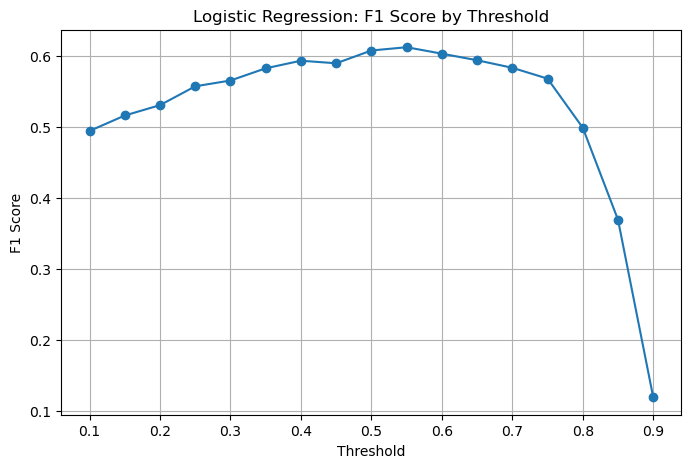

In [56]:
plt.figure(figsize=(8,5))
plt.plot(log_threshold_df["Threshold"], log_threshold_df["F1 Score"], marker='o')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Logistic Regression: F1 Score by Threshold")
plt.grid(True)
plt.show()

### Threshold Optimization

The default classification threshold for many models is 0.50, meaning customers with predicted churn probability greater than 50% are classified as churners. However, this threshold is not always optimal, especially in churn prediction where correctly identifying potential churners is important.

To improve model performance, multiple probability thresholds between 0.10 and 0.90 were evaluated using the F1 score as the primary metric. The results show that the optimal threshold is **0.40**, which produced the highest F1 score of **0.725**.

Using a slightly lower threshold allows the model to capture more potential churners while still maintaining a strong balance between precision and recall. This adjustment improves the model's ability to identify customers who may leave the service, making the predictions more useful for business retention strategies.

In [57]:
best_threshold = best_threshold_row["Threshold"]

gb_pred_best = (gb_prob >= best_threshold).astype(int)

print("Final F1:", f1_score(y_test, gb_pred_best))

Final F1: 0.7253044654939107


In [58]:
feature_importance = pd.Series(best_gb_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

tenure_days                       0.333002
tenure_months                     0.166091
InternetService_Fiber optic       0.147090
TotalCharges                      0.106758
MonthlyCharges                    0.099621
PaymentMethod_Electronic check    0.029927
Type_Two year                     0.021302
Type_One year                     0.013533
SeniorCitizen                     0.012541
TechSupport_Yes                   0.009532
dtype: float64

#### Here we learned that customer tenure was the strongest indicator of churn. If the customer had shorter tenure then the chances of them leaving was higher. Overall, shorter term years for services led to higher churn. 

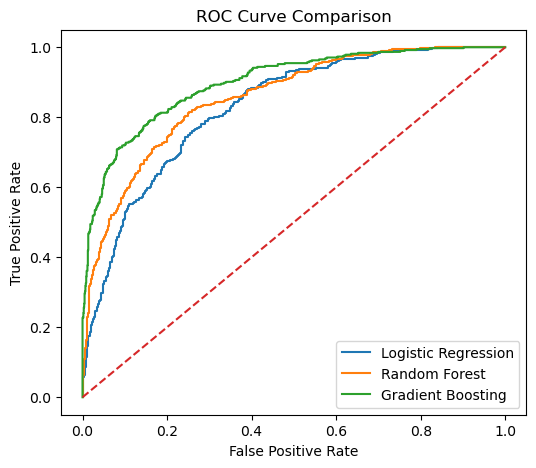

In [59]:

log_prob = best_log_model.predict_proba(X_test)[:,1]
rf_prob = best_rf_model.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,5))

for probs, label in [
    (log_prob, "Logistic Regression"),
    (rf_prob, "Random Forest"),
    (gb_prob, "Gradient Boosting")
]:

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=label)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()


#### Three models were evaluated: Logistic Regression, Random Forest, and Gradient Boosting. Logistic Regression served as a baseline model with ROC-AUC of 0.829. Random Forest improved performance to 0.853 ROC-AUC. Gradient Boosting produced the best results with ROC-AUC of 0.878 and the highest F1 score, indicating better performance in identifying churners. Therefore, Gradient Boosting was selected as the final model

# 5. Final Evaluation and Business Conclusions

#### Several machine learning models were evaluated to predict customer churn, including Logistic Regression, Random Forest, and Gradient Boosting. The models were compared using Accuracy, F1 Score, and ROC-AUC.

In [60]:


results_melt = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(data=results_melt, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

NameError: name 'results' is not defined

### Final Model Selection and Business Conclusions

Three machine learning models were evaluated to predict customer churn: Logistic Regression, Random Forest, and Gradient Boosting. The models were compared using Accuracy, F1 Score, and ROC-AUC.

The results were:


| Model | Accuracy | F1 Score | ROC-AUC |
|------|------|------|------|
| Logistic Regression | 0.7317 | 0.6054 | 0.8261 |
| Random Forest | 0.7871 | 0.6368 | 0.8567 |
| Gradient Boosting (threshold = 0.40) | **0.8644** | **0.7253** | **0.8985** |


Gradient Boosting clearly performed the best across all metrics, so it was selected as the final model.

---

### What These Metrics Mean (In Simple Terms)

**Accuracy (0.864)**  
Accuracy means how often the model is correct overall.  
An accuracy of **0.864** means the model correctly predicts whether a customer will stay or leave about **86% of the time**.

However, accuracy alone can sometimes be misleading in churn problems because most customers usually stay. This is why other metrics like F1 Score and ROC-AUC are also important.

---
**Precision (0.806)**  
Precision measures how often the model is correct when it predicts that a customer will churn.
• **Precision** → When the model predicts someone will churn, how often it is correct  

A precision score of **0.806** means that when the model identifies a customer as likely to leave, it is correct about **80% of the time**. In other words, most of the customers flagged by the model as potential churners actually do end up leaving. Higher precision helps reduce **false alarms**, where the model incorrectly predicts churn.


---

**Recall (0.644)**  
Recall measures how many of the customers who actually churned were successfully identified by the model.

A recall score of **0.644** means the model correctly identifies about **64% of the customers who eventually cancel their service**. For example, if **100 customers churn**, the model is able to detect about **64 of them in advance**.

• **Recall** → How many of the actual churners the model successfully catches

Recall is particularly important in churn prediction because businesses want to **identify as many at-risk customers as possible** so they can intervene and attempt to retain them before they cancel their service.

---
**F1 Score (0.725)**  
The **F1 score balances two things:**


An **F1 score of 0.725** means the model does a strong job **both identifying real churners and avoiding too many false alarms**.

In churn prediction, this metric is very important because businesses care more about **finding customers who might leave before they cancel their service**.

---

**ROC-AUC (0.898)**  
ROC-AUC measures how well the model separates customers who will churn from those who will stay.

A score of:

- **0.5 = random guessing**
- **1.0 = perfect prediction**

Your model achieved **0.898**, which means it has **very strong ability to distinguish between customers who will churn and those who will not**.

---

### Threshold Optimization

Instead of using the default classification threshold of **0.50**, multiple thresholds were tested to find the one that maximized the F1 score.

The optimal threshold was **0.40**, which produced the highest F1 score of **0.725**.

Using a slightly lower threshold allows the model to **identify more potential churners earlier**, which is useful for businesses that want to intervene before customers cancel their service.

---

### Key Drivers of Customer Churn

Feature importance from the Gradient Boosting model revealed the most influential factors affecting churn:

1. **Customer tenure (tenure_days / tenure_months)** – the strongest indicator  
2. **Internet service type (Fiber optic)**  
3. **Total charges and monthly charges**  
4. **Payment method (electronic check)**  
5. **Contract type**

This means customers who:

- Have **shorter tenure**
- Pay **higher monthly charges**
- Use **fiber optic service**
- Pay with **electronic checks**
- Have **short-term contracts**

are **more likely to cancel their service**.

---

### Business Insights

The results suggest that **newer customers are the most at risk of leaving**. This indicates that the early stage of the customer relationship is critical.

Companies could reduce churn by:

• Offering incentives for **longer-term contracts**  
• Providing **discounts or bundles for new customers**  
• Encouraging customers to adopt **additional services like technical support**  
• Targeting high-risk customers with **retention promotions**

By identifying customers who may churn early, the company can take proactive action to **improve customer retention, reduce marketing costs, and increase long-term customer value**.